# Monte Carlo over the firmware's FOC loop

The C under test is the firmware's own -- current loop, HF-injection
demodulator, rotor observer, dead-time table -- compiled for the host and
closed against a plant it was NOT told the truth about. Each run draws a
motor around the 5230SL's estimates (R to 125 C copper, L a quarter
either way, saliency 1.05-1.5, inertia half to double), a stage around
the commissioned one (dead time +/-20 %, knee +/-40 %), the AFE at its
measured noise floor, and a rotor the polarity pulse only roughly found.
Then it must lock at standstill, ramp a propeller to half the link's
no-load speed, hold, and come back to rest -- observed truth against the
observer the whole way.

**The stage, the critical numbers** (the rest import from
`coaxial.inverter`, traced from the schematic, the IAUCN10S7N021 model and
`half_bridge.asc`; docs/HARDWARE.md is the prose):

| | |
|---|---|
| switching | 50 kHz centre-aligned, ARR 2375 |
| dead time | **33.7 ns** held (DTG 8, OCP-trimmed); 65.4 ns is the sim's worst corner |
| minimum pulse | 76 ns -> 0.38 % duty, the injection floor |
| switch-node ring | 4 nH loop against 2 Coss: 31-39 MHz over 23-63 V, **Q = 1 assumed** -- a tight layout with crisp damping, not yet a scope trace |
| sample margin | ring settles < 50 ns, +143..153 ns of blanking left at the deepest duty |
| phase sense | 3.5 mohm shunt, 15.9 mV/A, floor **0.35-0.41 A rms measured** |

Everything below is arithmetic on that model -- no motor has turned, no
number here is a measurement (invariant 10).

In [1]:
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

root = Path.cwd()
while not (root / 'host' / 'coaxial').is_dir():
    root = root.parent
sys.path.insert(0, str(root / 'host'))
sys.path.insert(0, str(root / 'host' / 'tools'))

import montecarlo as mc
from coaxial import inverter, sensorless
from coaxial.motor import PLATINUM_5230SL as MOTOR

VDCS = (23.0, 33.0, 43.0, 53.0, 63.0)      # the link sweep
CANDIDATES, DRAWS, REFINE = 48, 16, 24     # search width
VERIFY_DRAWS = 48                          # fresh plants for the winners

BLUE, RED, GREY = '#1f4e79', '#c0392b', '#95a5a6'
VC = dict(zip(VDCS, ('#1f4e79', '#2e7d32', '#7a4e9e', '#c07820', '#c0392b')))
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.15})

pd.DataFrame({v: {'ring MHz': inverter.ring(v)['f_hz'] / 1e6,
                  'settle ns': inverter.ring(v)['settle_s'] * 1e9,
                  'blanking ns': inverter.blanking(v) * 1e9,
                  'v_dt V': inverter.dead_time_volts(v),
                  'knee A': inverter.knee_amps(v)} for v in VDCS}).round(2)

,23.0,33.0,43.0,53.0,63.0
ring MHz,31.47,34.06,36.11,37.83,39.31
settle ns,46.58,43.03,40.59,38.75,37.29
blanking ns,143.42,146.97,149.41,151.25,152.71
v_dt V,0.04,0.06,0.07,0.09,0.11
knee A,7.00,8.74,10.27,11.64,12.91


## The search

Eight knobs (current-loop and observer bandwidths, damping, injection
amplitude and length, the blend speeds, the speed loop), a Latin
hypercube of 48, 16 plant draws each, then a half-box refinement about
each link's best three. Cost per run: rms truth angle error + rms speed
error over top + 10 per stage trip; a candidate is scored mean + p90
over its draws, so a tune that is brilliant on the median and loses one
rotor in ten loses. One process per core.

In [2]:
t0 = time.perf_counter()
lib = mc.library()
with mc.pool(lib=lib) as p:
    best, runs = mc.search(p, VDCS, CANDIDATES, DRAWS, REFINE)
    ver = mc.verify(p, best, VERIFY_DRAWS)
print('%d runs in %.0f s' % (len(runs) + len(ver), time.perf_counter() - t0))

round 1: 3840 runs


    384 / 3840 runs, 8 s


    768 / 3840 runs, 15 s


   1152 / 3840 runs, 24 s


   1536 / 3840 runs, 32 s


...

    288 / 480 runs, 10 s


    336 / 480 runs, 12 s


    384 / 480 runs, 13 s


    432 / 480 runs, 14 s


    480 / 480 runs, 15 s
6240 runs in 147 s


## The controller the link voltage buys

`v_inj` is searched as a fraction of the link, and the optimum walks it
back as the link grows -- the columns below convert to volts and to the
HF current ripple they cost. `min rpm` is the sensorless floor: the
median and worst speed at which the back-EMF observer ALONE (injection
cut at the top of the hold) loses the rotor on the way down, over 48
fresh plants. With the injection left on, every descent below reaches
rest locked.

In [3]:
inj = ver[~ver.bemf_only].groupby('vdc')
dead = ver[ver.bemf_only].groupby('vdc')['min_rpm']
table = best.set_index('vdc')[list(mc.KNOBS)].copy()
table['v_inj V'] = [r.v_inj * r.vdc / math.sqrt(3.0) for r in best.itertuples()]
table['i_h A'] = inj['i_h'].first()
table['sigma_theta'] = inj['sigma_theta'].mean()
table['worst p90'] = inj['worst_theta'].quantile(0.9)
table['trips'] = inj['trip'].sum()
table['min rpm'] = dead.median()
table['min rpm p90'] = dead.quantile(0.9)
table.round(3)

,bw_i,f_pll,zeta,v_inj,n_inj,w_lo,w_ratio,bw_w,v_inj V,i_h A,sigma_theta,worst p90,trips,min rpm,min rpm p90
vdc,,,,,,,,,,,,,,,
23.0,313.133,77.374,0.978,0.198,4,544.604,2.648,8.708,2.623,4.770,0.048,0.433,0,37.875,47.021
33.0,1920.023,53.509,0.875,0.197,2,79.514,1.511,9.360,3.751,3.410,0.032,0.333,0,23.545,35.988
43.0,2263.726,73.699,0.654,0.196,2,133.067,2.019,8.426,4.862,4.420,0.037,0.272,0,42.376,57.831
53.0,540.051,77.666,0.752,0.114,2,164.220,3.907,5.381,3.489,3.172,0.054,0.367,0,25.887,39.312
63.0,947.229,55.707,1.022,0.055,2,185.536,1.586,1.475,1.989,1.808,0.074,0.563,0,69.108,174.541


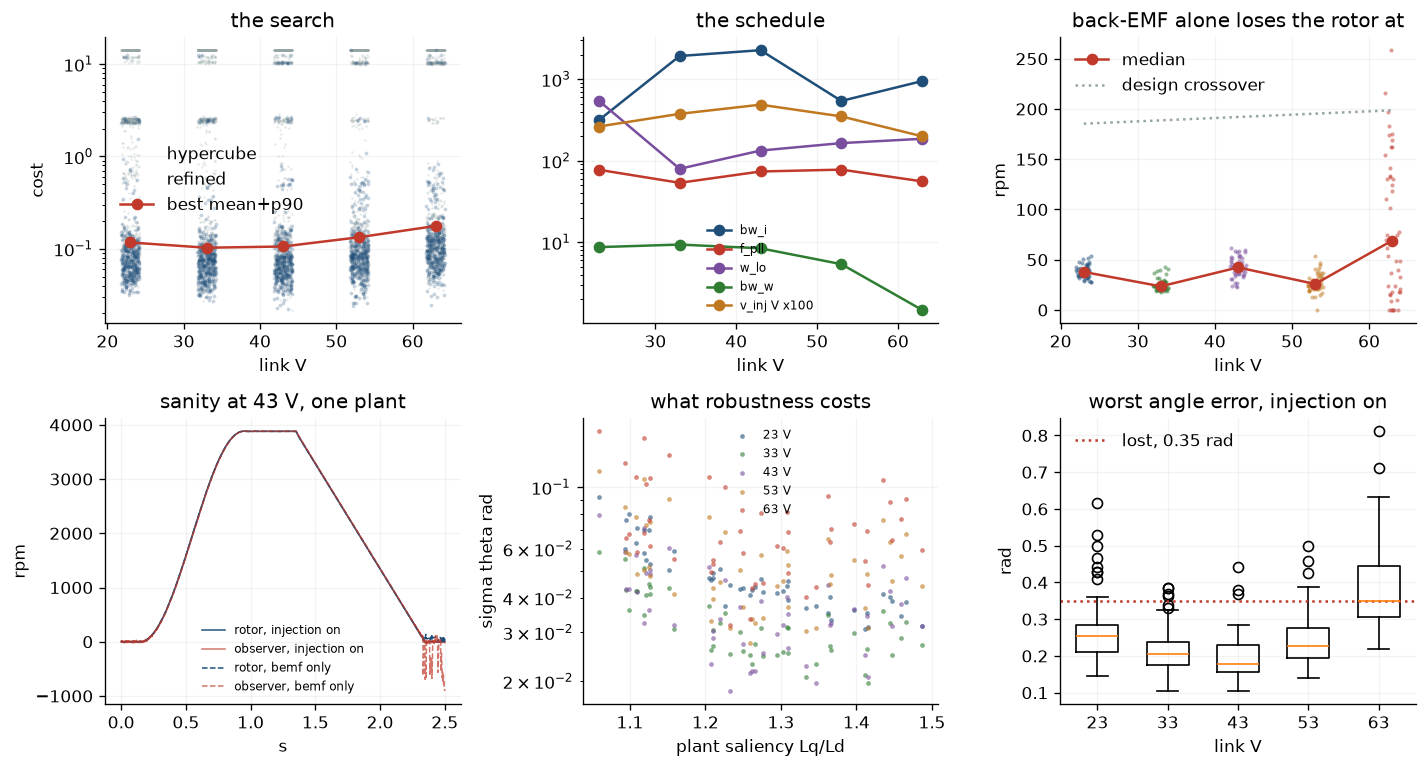

In [4]:
fig, ax = plt.subplots(2, 3, figsize=(12, 6.5))

a = ax[0, 0]
for r, m, lab in ((1, 2, 'hypercube'), (2, 5, 'refined')):
    sub = runs[runs['round'] == r]
    a.scatter(sub.vdc + np.random.default_rng(r).uniform(-1.2, 1.2, len(sub)),
              sub.cost, s=m, color=GREY if r == 1 else BLUE, alpha=0.25,
              lw=0, label=lab)
a.plot(best.vdc, best.robust, color=RED, marker='o', label='best mean+p90')
a.set(title='the search', xlabel='link V', ylabel='cost', yscale='log')
a.legend(frameon=False)

a = ax[0, 1]
for name, color in (('bw_i', BLUE), ('f_pll', RED), ('w_lo', '#7a4e9e'),
                    ('bw_w', '#2e7d32')):
    a.plot(best.vdc, best[name], marker='o', color=color, label=name)
a.plot(best.vdc, [r.v_inj * r.vdc / math.sqrt(3.0) * 100 for r in
                  best.itertuples()], marker='o', color='#c07820',
       label='v_inj V x100')
a.set(title='the schedule', xlabel='link V', yscale='log')
a.legend(frameon=False, fontsize=7)

a = ax[0, 2]
d = ver[ver.bemf_only]
for v in VDCS:
    s = d[d.vdc == v].min_rpm
    a.scatter(np.full(len(s), v) + np.random.default_rng(int(v)).uniform(
        -1.0, 1.0, len(s)), s, s=6, color=VC[v], alpha=0.5, lw=0)
a.plot(VDCS, [d[d.vdc == v].min_rpm.median() for v in VDCS], color=RED,
       marker='o', label='median')
cross = [sensorless.crossover(MOTOR.lam, MOTOR.r, mc.I_MAX,
                              0.2 * inverter.dead_time_volts(v),
                              pole_pairs=MOTOR.poles)['rpm'] for v in VDCS]
a.plot(VDCS, cross, color=GREY, ls=':', label='design crossover')
a.set(title='back-EMF alone loses the rotor at', xlabel='link V',
      ylabel='rpm')
a.legend(frameon=False)

a = ax[1, 0]
i = best.vdc.searchsorted(43.0)
knobs = {k: float(best.loc[i, k]) for k in mc.KNOBS}
mc._load(lib)
tr = mc.run_job({'vdc': 43.0, 'knobs': knobs, 'seed': 90001, 'trace': 1})
td = mc.run_job({'vdc': 43.0, 'knobs': knobs, 'seed': 90001, 'trace': 1,
                 'bemf_only': True})
for run, ls, lab in ((tr, '-', 'injection on'), (td, '--', 'bemf only')):
    t, wr, w, wh = (np.array([r[c] for r in run['trace']]) for c in range(4))
    a.plot(t, w * 60 / (2 * math.pi * MOTOR.poles), ls, color=BLUE, lw=0.9,
           label='rotor, ' + lab)
    a.plot(t, wh * 60 / (2 * math.pi * MOTOR.poles), ls, color=RED, lw=0.9,
           alpha=0.7, label='observer, ' + lab)
a.set(title='sanity at 43 V, one plant', xlabel='s', ylabel='rpm')
a.legend(frameon=False, fontsize=7)

a = ax[1, 1]
v = ver[~ver.bemf_only]
for vd in VDCS:
    s = v[v.vdc == vd]
    a.scatter(s.saliency, s.sigma_theta, s=8, color=VC[vd], alpha=0.6, lw=0,
              label='%.0f V' % vd)
a.set(title='what robustness costs', xlabel='plant saliency Lq/Ld',
      ylabel='sigma theta rad', yscale='log')
a.legend(frameon=False, fontsize=7)

a = ax[1, 2]
data = [v[v.vdc == vd].worst_theta for vd in VDCS]
a.boxplot(data, positions=list(VDCS), widths=6, tick_labels=[
    '%.0f' % x for x in VDCS])
a.axhline(mc.LOST, color=RED, ls=':', label='lost, %.2f rad' % mc.LOST)
a.set(title='worst angle error, injection on', xlabel='link V',
      ylabel='rad')
a.legend(frameon=False)

fig.tight_layout()

## What it says

* **One controller does not fit the sweep.** The injection wants roughly
  constant VOLTS (so its knob falls as the link rises), the observer sits
  in the same few tens of Hz everywhere, and the blend point scales with
  the speed range the link buys.
* **The optimised blend beats the envelope arithmetic.** `sensorless.crossover` with its margin of 3 and a 20 % dead-time residual puts the back-EMF handover near 190 rpm; the searched controller holds the rotor to a median 24-69 rpm before losing it - the margin the Kalman-form blend buys over the back-of-envelope.
* **The sensorless floor is the descent, not the standstill.** With
  injection on, every run reaches rest locked; on back-EMF alone the
  rotor is lost tens of rpm above zero, later in rpm at 63 V because the
  same one-second descent falls faster.
* All of it inherits the header's assumptions -- above all **Q = 1 on the
  ring** and a dead-time table within +/-20 % of truth. TODO 6's scope
  trace and a real identification replace them; `tools/commission.py` is
  where these numbers meet a winding.